In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

plt.rcParams["font.family"] = "serif"

In [36]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [37]:
df = pd.read_csv("../results/benchmark_batched_gemv.csv")
df["times (ms)"] = df["times (ms)"].apply(ast.literal_eval)
df["time (ms)"] = df["times (ms)"].apply(min)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms)
0,16777216,2,float32,float32,custom,"[0.33116031646728517, 0.330968017578125, 0.331...",2.539268e-04,0.328005
1,16777216,2,float32,float32,torch,"[16.48303680419922, 16.45647735595703, 16.4344...",3.006736e-04,16.433894
2,16777216,2,float16,float32,custom,"[0.25565055847167967, 0.25685600280761717, 0.2...",2.538121e-04,0.255651
3,16777216,2,float16,float32,torch,"[17.938134765625, 17.952391052246092, 17.95425...",2.403529e+00,17.933652
4,16777216,2,bfloat16,float32,custom,"[0.2616559982299805, 0.25629152297973634, 0.25...",2.537925e-04,0.256117
...,...,...,...,...,...,...,...,...
1787,4032,129,float64,float64,torch,"[0.32136192321777346, 0.3227286529541016, 0.32...",0.000000e+00,0.321362
1788,4032,129,float16,float64,custom,"[0.13934816360473634, 0.13333215713500976, 0.1...",3.510356e-12,0.133328
1789,4032,129,float16,float64,torch,"[0.11532159805297852, 0.11683072090148926, 0.1...",2.404200e+00,0.115322
1790,4032,129,bfloat16,float64,custom,"[0.13586336135864258, 0.13392288208007813, 0.1...",3.497592e-12,0.133822


In [38]:
def throughput(n, k, time_ms, mat_dtype, vec_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [39]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [40]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"],
        k=row["k"],
        time_ms=row["time (ms)"],
        mat_dtype=row["A_dtype"],
        vec_dtype=row["b_dtype"],
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms),throughput,GFlops
0,16777216,2,float32,float32,custom,"[0.33116031646728517, 0.330968017578125, 0.331...",2.539268e-04,0.328005,1636.776091,409.194023
1,16777216,2,float32,float32,torch,"[16.48303680419922, 16.45647735595703, 16.4344...",3.006736e-04,16.433894,32.668514,8.167129
2,16777216,2,float16,float32,custom,"[0.25565055847167967, 0.25685600280761717, 0.2...",2.538121e-04,0.255651,1575.013903,525.004634
3,16777216,2,float16,float32,torch,"[17.938134765625, 17.952391052246092, 17.95425...",2.403529e+00,17.933652,22.452381,7.484127
4,16777216,2,bfloat16,float32,custom,"[0.2616559982299805, 0.25629152297973634, 0.25...",2.537925e-04,0.256117,1572.142784,524.047595
...,...,...,...,...,...,...,...,...,...,...
1787,4032,129,float64,float64,torch,"[0.32136192321777346, 0.3227286529541016, 0.32...",0.000000e+00,0.321362,1696.200155,417.575992
1788,4032,129,float16,float64,custom,"[0.13934816360473634, 0.13333215713500976, 0.1...",3.510356e-12,0.133328,1068.903204,1006.485498
1789,4032,129,float16,float64,torch,"[0.11532159805297852, 0.11683072090148926, 0.1...",2.404200e+00,0.115322,1235.805559,1163.641731
1790,4032,129,bfloat16,float64,custom,"[0.13586336135864258, 0.13392288208007813, 0.1...",3.497592e-12,0.133822,1064.961840,1002.774287


In [41]:
def plot_throughput(ax, mat_dtype: str, vec_dtype: str, labels: bool = False):
    max_tput = df[
        (df.A_dtype == mat_dtype) & (df.b_dtype == vec_dtype) & (df.k <= 128)
    ].pivot_table(values="throughput", columns="algorithm", index="k", aggfunc="max")

    title = f"{mat_dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=130)

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    ax.scatter(
        x=max_tput.index,
        y=max_tput["custom"],
        marker="^",
        label="Our implementation" if labels else None,
        s=13,
        zorder=3,
        facecolors="none",
        edgecolors="tab:blue",
    )
    ax.scatter(
        x=max_tput.index,
        y=max_tput["torch"],
        marker="o",
        label="PyTorch" if labels else None,
        s=13,
        zorder=2,
        facecolors="none",
        edgecolors="tab:orange",
    )
    ax.axhline(
        y=2039,
        color="red",
        linestyle="--",
        label="A100 bandwidth (2,039GB/s)" if labels else None,
    )

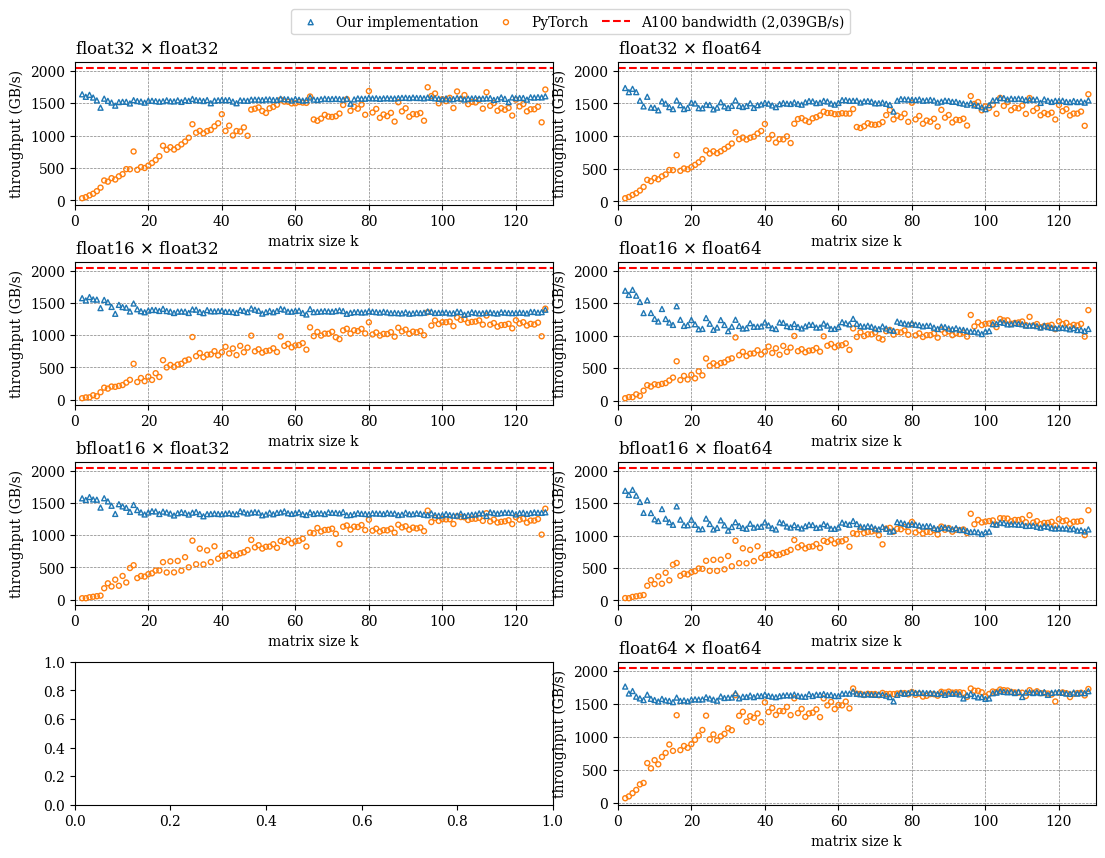

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8))
fig.tight_layout(pad=1.0, h_pad=2.0)
for i, mat_dtype in enumerate(df.A_dtype.unique()):
    for j, vec_dtype in enumerate(df.b_dtype.unique()):
        if mat_dtype == "float64" and vec_dtype == "float32":
            continue
        plot_throughput(axes[i, j], mat_dtype, vec_dtype, labels=(i == 0 and j == 0))

fig.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
# fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

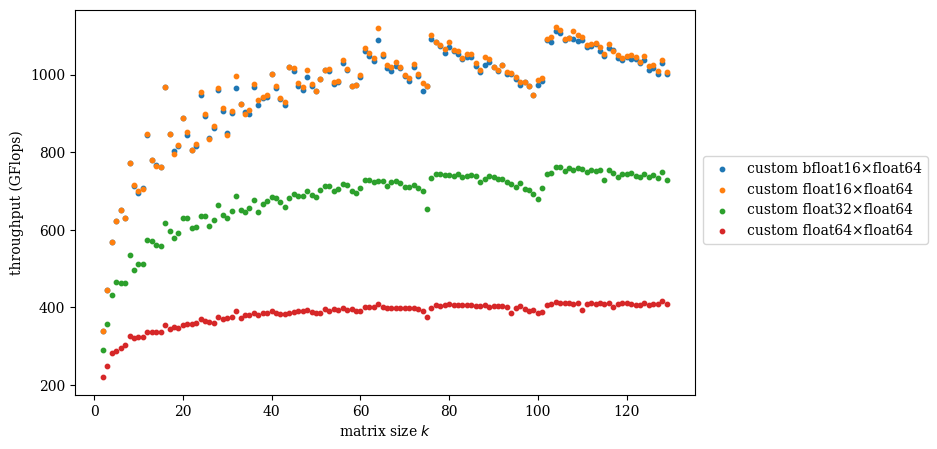

In [43]:
max_tput = df.pivot_table(
    values="GFlops",
    columns=["algorithm", "A_dtype", "b_dtype"],
    index="k",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    if col[2] == "float64" and col[0] == "custom":
        ax.scatter(
            max_tput.index,
            max_tput[col],
            label=col[0] + " " + col[1] + "×" + col[2],
            s=10,
        )

fig.legend(loc="right", bbox_to_anchor=(1.2, 0.5))